In [1]:
import json
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
with open("data/platform_data.json", "r") as f:
    data = json.load(f)

platforms = data["platforms"]
market = data["market_data"]
categories = data["category_benchmarks"]

print("✅ Data loaded successfully")
print(f"Platforms: {list(platforms.keys())}")
print(f"Categories: {list(categories.keys())}")

✅ Data loaded successfully
Platforms: ['blinkit', 'zepto', 'instamart']
Categories: ['FMCG', 'Personal Care', 'Snacks', 'Beverages', 'Beauty', 'Grocery', 'Fashion', 'Electronics']


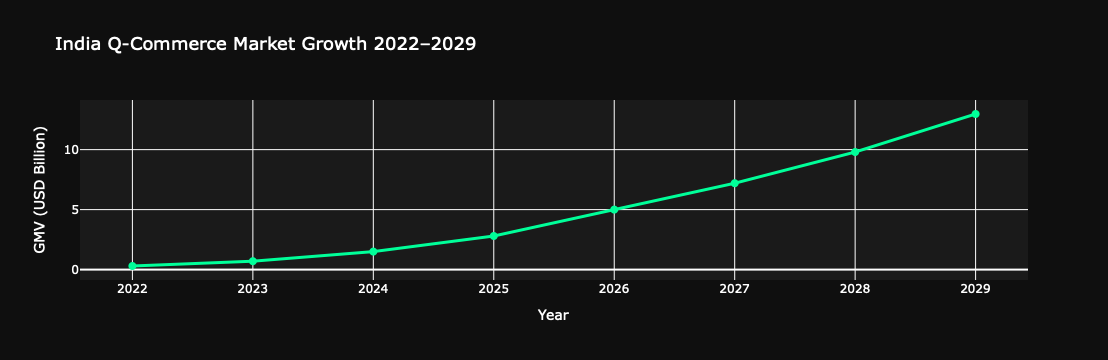


📈 Market growing at 40% YoY
📦 Projected market size by 2029: $12.97B


In [3]:
# Market size data
market_df = pd.DataFrame({
    "Year": [2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029],
    "GMV (USD Billion)": [0.3, 0.7, 1.5, 2.8, 5.0, 7.2, 9.8, 12.97]
})

fig = px.line(
    market_df, x="Year", y="GMV (USD Billion)",
    title="India Q-Commerce Market Growth 2022–2029",
    markers=True,
    color_discrete_sequence=["#00ff99"]
)
fig.update_layout(
    paper_bgcolor="#0f0f0f",
    plot_bgcolor="#1a1a1a",
    font_color="white",
    title_font_size=18
)
fig.update_traces(line_width=3, marker_size=8)
fig.show()

print(f"\n📈 Market growing at {market['yoy_growth_percent']}% YoY")
print(f"📦 Projected market size by 2029: ${market['projected_market_2029_usd_billion']}B")

        Platform  Market Share (%)  Commission Rate (%)  Fulfillment Fee (₹)  Min Monthly Ad Spend (₹)  Dark Stores  Cities Active
         Blinkit              50.0                 18.0                   50                    250000          500             30
           Zepto              29.0                 20.0                   45                    500000          250             20
Swiggy Instamart              23.0                 15.0                   40                    200000          400             25


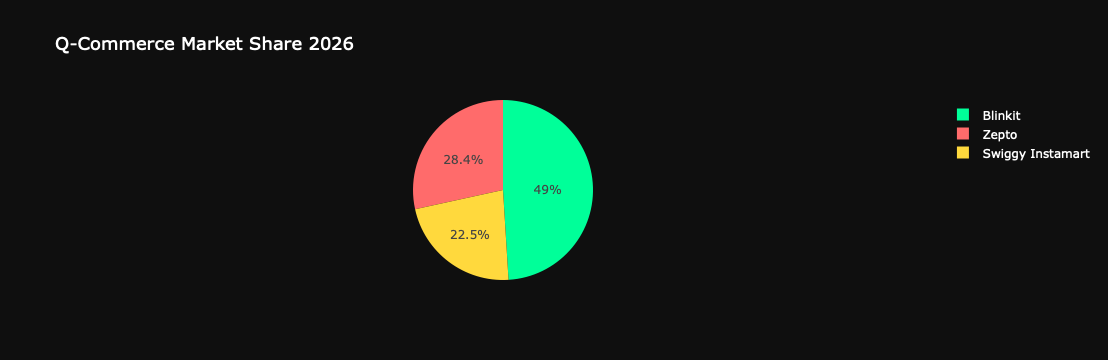

In [4]:
# Platform comparison data
platform_df = pd.DataFrame([{
    "Platform": platforms[k]["name"],
    "Market Share (%)": platforms[k]["market_share"] * 100,
    "Commission Rate (%)": platforms[k]["commission_rate"] * 100,
    "Fulfillment Fee (₹)": platforms[k]["fulfillment_fee_per_order"],
    "Min Monthly Ad Spend (₹)": platforms[k]["min_monthly_ad_spend"],
    "Dark Stores": platforms[k]["dark_stores"],
    "Cities Active": platforms[k]["cities_active"]
} for k in platforms])

print(platform_df.to_string(index=False))

# Market share pie chart
fig = px.pie(
    platform_df,
    names="Platform",
    values="Market Share (%)",
    title="Q-Commerce Market Share 2026",
    color_discrete_sequence=["#00ff99", "#ff6b6b", "#ffd93d"]
)
fig.update_layout(
    paper_bgcolor="#0f0f0f",
    font_color="white",
    title_font_size=18
)
fig.show()

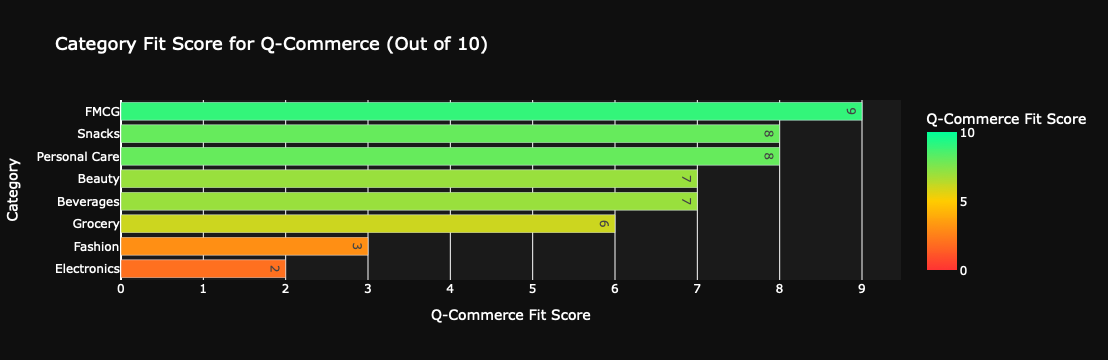


🏆 Best categories for Q-Commerce:
     Category  Q-Commerce Fit Score
Personal Care                     8
       Snacks                     8
         FMCG                     9

⚠️ Worst categories for Q-Commerce:
   Category  Q-Commerce Fit Score
Electronics                     2
    Fashion                     3


In [5]:
# Category fit scores
cat_df = pd.DataFrame([{
    "Category": cat,
    "Q-Commerce Fit Score": categories[cat]["qcommerce_fit_score"],
    "Avg Gross Margin (%)": categories[cat]["avg_gross_margin"] * 100,
    "Repeat Purchase Rate (%)": categories[cat]["repeat_purchase_rate"] * 100
} for cat in categories])

cat_df = cat_df.sort_values("Q-Commerce Fit Score", ascending=True)

fig = px.bar(
    cat_df,
    x="Q-Commerce Fit Score",
    y="Category",
    orientation="h",
    title="Category Fit Score for Q-Commerce (Out of 10)",
    color="Q-Commerce Fit Score",
    color_continuous_scale=["#ff3333", "#ffcc00", "#00ff99"],
    range_color=[0, 10],
    text="Q-Commerce Fit Score"
)
fig.update_layout(
    paper_bgcolor="#0f0f0f",
    plot_bgcolor="#1a1a1a",
    font_color="white",
    title_font_size=18
)
fig.show()

print("\n🏆 Best categories for Q-Commerce:")
print(cat_df.tail(3)[["Category", "Q-Commerce Fit Score"]].to_string(index=False))
print("\n⚠️ Worst categories for Q-Commerce:")
print(cat_df.head(2)[["Category", "Q-Commerce Fit Score"]].to_string(index=False))

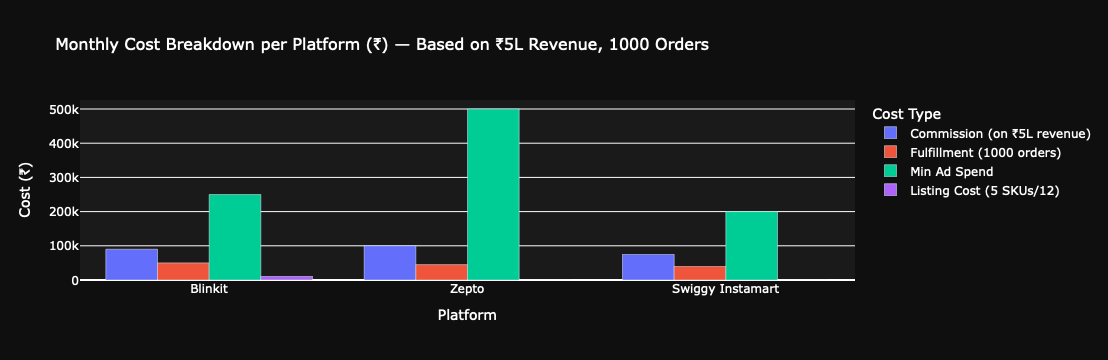


💸 Total platform costs comparison:
Blinkit: ₹390,000/month
Zepto: ₹645,000/month
Swiggy Instamart: ₹315,000/month


In [6]:
# Cost comparison across platforms
cost_df = pd.DataFrame([{
    "Platform": platforms[k]["name"],
    "Commission (on ₹5L revenue)": platforms[k]["commission_rate"] * 500000,
    "Fulfillment (1000 orders)": platforms[k]["fulfillment_fee_per_order"] * 1000,
    "Min Ad Spend": platforms[k]["min_monthly_ad_spend"],
    "Listing Cost (5 SKUs/12)": (platforms[k]["listing_fee_per_sku"] * 5) / 12
} for k in platforms])

fig = px.bar(
    cost_df.melt(id_vars="Platform"),
    x="Platform",
    y="value",
    color="variable",
    barmode="group",
    title="Monthly Cost Breakdown per Platform (₹) — Based on ₹5L Revenue, 1000 Orders",
    labels={"value": "Cost (₹)", "variable": "Cost Type"}
)
fig.update_layout(
    paper_bgcolor="#0f0f0f",
    plot_bgcolor="#1a1a1a",
    font_color="white",
    title_font_size=16
)
fig.show()

print("\n💸 Total platform costs comparison:")
for k in platforms:
    p = platforms[k]
    total = (p["commission_rate"] * 500000) + (p["fulfillment_fee_per_order"] * 1000) + p["min_monthly_ad_spend"]
    print(f"{p['name']}: ₹{total:,.0f}/month")


In [9]:
insights = """
╔══════════════════════════════════════════════════════════════════╗
║         Q-COMMERCE ENTRY ANALYSIS — KEY FINDINGS 2026            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MARKET                                                          ║
║  • India Q-Commerce market hit $5B GMV in 2026                   ║
║  • Growing at 40% YoY — projected $12.97B by 2029                ║
║  • 68% of D2C brands fail to break even on platforms             ║
║  • Average platform take rate: 42% of selling price              ║
║                                                                  ║
║  PLATFORM VERDICT                                                ║
║  • Blinkit — Best reach, 50% market share, high cost             ║
║  • Zepto — Highest ad spend, best for Gen Z brands               ║
║  • Instamart — Lowest fees, best entry point for new brands      ║
║                                                                  ║
║  CATEGORY WINNERS                                                ║
║  • FMCG, Personal Care, Snacks = High fit (score 8-9/10)         ║
║  • Fashion, Electronics = Avoid Q-Commerce (score 2-3/10)        ║
║                                                                  ║
║  RECOMMENDATION                                                  ║
║  • Brands with <₹600 AOV need 2000+ monthly orders to survive    ║
║  • Start with Instamart → prove unit economics → expand          ║
║  • Minimum viable ad budget: ₹2L/month across all platforms      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(insights)


╔══════════════════════════════════════════════════════════════════╗
║         Q-COMMERCE ENTRY ANALYSIS — KEY FINDINGS 2026            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MARKET                                                          ║
║  • India Q-Commerce market hit $5B GMV in 2026                   ║
║  • Growing at 40% YoY — projected $12.97B by 2029                ║
║  • 68% of D2C brands fail to break even on platforms             ║
║  • Average platform take rate: 42% of selling price              ║
║                                                                  ║
║  PLATFORM VERDICT                                                ║
║  • Blinkit — Best reach, 50% market share, high cost             ║
║  • Zepto — Highest ad spend, best for Gen Z brands               ║
║  • Instamart — Lowest fees, best entry point for new brands      ║
║                                

In [10]:
# Final platform recommendation summary
summary_df = pd.DataFrame([{
    "Platform": platforms[k]["name"],
    "Market Share": f"{platforms[k]['market_share']*100}%",
    "Commission": f"{platforms[k]['commission_rate']*100}%",
    "Min Ad Spend": f"₹{platforms[k]['min_monthly_ad_spend']:,}",
    "Best For": ", ".join(platforms[k]["best_categories"][:2]),
    "Target Audience": platforms[k]["target_audience"],
    "Entry Difficulty": "High" if platforms[k]["min_monthly_ad_spend"] >= 500000 else "Medium" if platforms[k]["min_monthly_ad_spend"] >= 250000 else "Low"
} for k in platforms])

print("=" * 80)
print("PLATFORM SELECTION GUIDE — Q-COMMERCE 2026")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)
print("\n✅ Analysis Complete — Q-Commerce Entry Analyzer by Bharanidhar S")
print("📊 Tool built to help Indian D2C brands make data-driven platform decisions")

PLATFORM SELECTION GUIDE — Q-COMMERCE 2026
        Platform        Market Share Commission Min Ad Spend            Best For                                         Target Audience Entry Difficulty
         Blinkit               50.0%      18.0%     ₹250,000 FMCG, Personal Care                       Urban millennials, premium buyers           Medium
           Zepto 28.999999999999996%      20.0%     ₹500,000   Snacks, Beverages                Gen Z, urban millennials, impulse buyers             High
Swiggy Instamart               23.0%      15.0%     ₹200,000       Grocery, FMCG Existing Swiggy food users, families, daily need buyers              Low

✅ Analysis Complete — Q-Commerce Entry Analyzer by Bharanidhar S
📊 Tool built to help Indian D2C brands make data-driven platform decisions


In [2]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           CASE STUDY — MAMAEARTH x Q-COMMERCE 2026               ║
║        Should Mamaearth Deepen Its Quick Commerce Presence?      ║
╠══════════════════════════════════════════════════════════════════╣
║  Brand     : Mamaearth (Honasa Consumer Ltd)                     ║
║  Category  : Personal Care / Beauty                              ║
║  Analyst   : Bharanidhar S                                       ║
║  Date      : May 2026                                            ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           CASE STUDY — MAMAEARTH x Q-COMMERCE 2026               ║
║        Should Mamaearth Deepen Its Quick Commerce Presence?      ║
╠══════════════════════════════════════════════════════════════════╣
║  Brand     : Mamaearth (Honasa Consumer Ltd)                     ║
║  Category  : Personal Care / Beauty                              ║
║  Analyst   : Bharanidhar S                                       ║
║  Date      : May 2026                                            ║
╚══════════════════════════════════════════════════════════════════╝



In [3]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — BRAND OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Mamaearth, owned by Honasa Consumer Ltd, is India's largest D2C
personal care brand built on a toxin-free, natural ingredients
positioning. Founded in 2016 by Varun & Ghazal Alagh, it has
grown into a multi-brand house including The Derma Co, Aqualogica,
BBlunt, and Dr Sheth's.

KEY FINANCIALS (FY26):
  • Q3 FY26 Revenue     : ₹601.5 crore (16% YoY growth)
  • Gross Margin        : ~70.5%
  • EBITDA Margin       : ~8.9%
  • Market Cap          : ~$1.03 Billion
  • Distribution Reach  : 2.7 lakh outlets across India
  • Direct Outlets      : 1 lakh+ (crossed Q3 FY26)

CURRENT CHANNEL MIX:
  • Own website (D2C)
  • Amazon, Flipkart, Nykaa (marketplaces)
  • Offline retail (rapidly expanding)
  • Quick Commerce — present but not scaled

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 1 — BRAND OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Mamaearth, owned by Honasa Consumer Ltd, is India's largest D2C
personal care brand built on a toxin-free, natural ingredients
positioning. Founded in 2016 by Varun & Ghazal Alagh, it has
grown into a multi-brand house including The Derma Co, Aqualogica,
BBlunt, and Dr Sheth's.

KEY FINANCIALS (FY26):
  • Q3 FY26 Revenue     : ₹601.5 crore (16% YoY growth)
  • Gross Margin        : ~70.5%
  • EBITDA Margin       : ~8.9%
  • Market Cap          : ~$1.03 Billion
  • Distribution Reach  : 2.7 lakh outlets across India
  • Direct Outlets      : 1 lakh+ (crossed Q3 FY26)

CURRENT CHANNEL MIX:
  • Own website (D2C)
  • Amazon, Flipkart, Nykaa (marketplaces)
  • Offline retail (rapidly expanding)
  • Quick Commerce — present but not scaled

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [4]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — THE BUSINESS QUESTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONTEXT:
  India's Q-Commerce market hit $7.6B GMV in FY25, growing 40% YoY.
  Blinkit, Zepto and Instamart now control urban FMCG discovery.
  68% of D2C brands fail to break even on these platforms.

THE QUESTION:
  Should Mamaearth aggressively scale its Quick Commerce presence
  across Blinkit, Zepto and Swiggy Instamart in 2026 — or will
  platform fees erode the margins they have worked hard to rebuild?

WHY THIS MATTERS:
  • Mamaearth's gross margin recovered to 70.5% in FY26
  • They are aggressively expanding offline distribution
  • Q-Commerce risks cannibalizing their own D2C channel
  • Platform take rates average 42% — a direct threat to EBITDA

THIS ANALYSIS WILL:
  ✅ Calculate platform-wise profitability using real unit economics
  ✅ Identify which platform offers the best risk-adjusted entry
  ✅ Recommend a Q-Commerce strategy for Mamaearth's CMO

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 2 — THE BUSINESS QUESTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONTEXT:
  India's Q-Commerce market hit $7.6B GMV in FY25, growing 40% YoY.
  Blinkit, Zepto and Instamart now control urban FMCG discovery.
  68% of D2C brands fail to break even on these platforms.

THE QUESTION:
  Should Mamaearth aggressively scale its Quick Commerce presence
  across Blinkit, Zepto and Swiggy Instamart in 2026 — or will
  platform fees erode the margins they have worked hard to rebuild?

WHY THIS MATTERS:
  • Mamaearth's gross margin recovered to 70.5% in FY26
  • They are aggressively expanding offline distribution
  • Q-Commerce risks cannibalizing their own D2C channel
  • Platform take rates average 42% — a direct threat to EBITDA

THIS ANALYSIS WILL:
  ✅ Calculate platform-wise profitability using real unit economics
  ✅ Identify which platform offers the best risk-adjusted entry
  ✅ Recommend a

In [5]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 3 — ASSUMPTIONS & INPUTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

All inputs are derived from publicly available data sources
including Honasa Consumer Q3 FY26 earnings, industry reports,
and platform disclosures.

BRAND INPUTS:
  • COGS per unit          : ₹135  (30% of AOV — from 70% gross margin)
  • Average Order Value    : ₹450  (Mamaearth mid-range product basket)
  • Customer Acq. Cost     : ₹90   (Personal care D2C benchmark FY26)
  • Expected Monthly Orders: 2,000 (Conservative Q-Commerce estimate)
  • Number of SKUs         : 10    (Top performing SKUs for Q-Commerce)
  • Product Category       : Personal Care

SOURCES:
  • Honasa Consumer Q3 FY26 Earnings Report
  • Inc42 Q-Commerce Market Report 2026
  • GlobalWebsters Q-Commerce Strategy Guide 2026
  • Platform fee data from public seller disclosures

NOTE ON METHODOLOGY:
  This analysis uses the Q-Commerce Entry Analyzer tool built
  specifically for Indian D2C brands. The tool models platform
  costs including commission, fulfillment, ad spend and listing
  fees against brand unit economics to produce a Go/No-Go score.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 3 — ASSUMPTIONS & INPUTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

All inputs are derived from publicly available data sources
including Honasa Consumer Q3 FY26 earnings, industry reports,
and platform disclosures.

BRAND INPUTS:
  • COGS per unit          : ₹135  (30% of AOV — from 70% gross margin)
  • Average Order Value    : ₹450  (Mamaearth mid-range product basket)
  • Customer Acq. Cost     : ₹90   (Personal care D2C benchmark FY26)
  • Expected Monthly Orders: 2,000 (Conservative Q-Commerce estimate)
  • Number of SKUs         : 10    (Top performing SKUs for Q-Commerce)
  • Product Category       : Personal Care

SOURCES:
  • Honasa Consumer Q3 FY26 Earnings Report
  • Inc42 Q-Commerce Market Report 2026
  • GlobalWebsters Q-Commerce Strategy Guide 2026
  • Platform fee data from public seller disclosures

NOTE ON METHODOLOGY:
  This analysis uses the Q-Commerce Entry Analyzer too

In [6]:
import sys
sys.path.append('/Users/bharanidhars/Desktop/qcommerce-analyzer')

from calculator import analyze_all_platforms
import pandas as pd

# Mamaearth real inputs
results = analyze_all_platforms(
    cogs=135,
    aov=450,
    cac=90,
    monthly_orders=2000,
    num_skus=10,
    category="Personal Care"
)

# Display results
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("SECTION 4 — TOOL OUTPUT (Q-Commerce Entry Analyzer)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"\nBrand: Mamaearth | Category: Personal Care | Monthly Orders: 2,000\n")

for key in ["blinkit", "zepto", "instamart"]:
    r = results[key]
    print(f"PLATFORM : {r['platform']}")
    print(f"VERDICT  : {r['verdict']}")
    print(f"SCORE    : {r['score']}/100")
    print(f"Revenue  : ₹{r['gross_revenue']:,.0f}")
    print(f"Platform Cost : ₹{r['total_platform_cost']:,.0f}")
    print(f"Net Profit    : ₹{r['net_profit']:,.0f}")
    print(f"Profit Margin : {r['profit_margin']}%")
    print(f"Platform Take : {r['platform_take_rate']}%")
    print("─" * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 4 — TOOL OUTPUT (Q-Commerce Entry Analyzer)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Brand: Mamaearth | Category: Personal Care | Monthly Orders: 2,000

PLATFORM : Blinkit
VERDICT  : ❌ NO-GO
SCORE    : 34/100
Revenue  : ₹900,000
Platform Cost : ₹532,833
Net Profit    : ₹-82,833
Profit Margin : -9.2%
Platform Take : 59.2%
──────────────────────────────────────────────────
PLATFORM : Zepto
VERDICT  : ❌ NO-GO
SCORE    : 24/100
Revenue  : ₹900,000
Platform Cost : ₹770,000
Net Profit    : ₹-320,000
Profit Margin : -35.56%
Platform Take : 85.56%
──────────────────────────────────────────────────
PLATFORM : Swiggy Instamart
VERDICT  : ⚠️ PROCEED WITH CAUTION
SCORE    : 59/100
Revenue  : ₹900,000
Platform Cost : ₹415,000
Net Profit    : ₹35,000
Profit Margin : 3.89%
Platform Take : 46.11%
──────────────────────────────────────────────────


In [7]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 5 — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — Zepto is a value destroyer for Mamaearth
  Platform take rate of 85.56% on ₹9L revenue means Zepto
  consumes nearly all revenue before Mamaearth earns a rupee.
  Net loss of ₹3,20,000/month makes this platform commercially
  unviable at current order volumes.
  → Zepto's ₹5,00,000 minimum ad spend is the primary killer.

FINDING 2 — Blinkit is expensive but closer to breakeven
  At 59.2% platform take rate, Blinkit is costly but not as
  catastrophic as Zepto. The ₹82,833 monthly loss could be
  recovered with higher order volumes (3,500+ orders/month)
  or a higher AOV product mix (₹600+ basket).
  → Blinkit becomes viable if Mamaearth pushes premium SKUs.

FINDING 3 — Instamart is the only viable entry point
  Score of 59/100 with ₹35,000 net profit at just 2,000 orders
  makes Instamart the clear winner. Lowest take rate (46.11%)
  and lowest minimum ad spend (₹2,00,000) give Mamaearth room
  to test and learn without bleeding cash.
  → Start here. Prove unit economics. Then expand.

FINDING 4 — Q-Commerce cannibalizes D2C margins
  Mamaearth's gross margin on its own website is ~70.5%.
  On Q-Commerce platforms, effective margin drops to 3.89%
  at best (Instamart). This 66% margin compression is a
  structural risk to Honasa's profitability recovery story.

FINDING 5 — Volume is the only cure
  Every platform becomes more viable at higher order volumes
  because fixed costs (ad spend, listing) get spread across
  more orders. Mamaearth needs 4,000+ monthly orders per
  platform before Q-Commerce makes strategic sense.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 5 — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

FINDING 1 — Zepto is a value destroyer for Mamaearth
  Platform take rate of 85.56% on ₹9L revenue means Zepto
  consumes nearly all revenue before Mamaearth earns a rupee.
  Net loss of ₹3,20,000/month makes this platform commercially
  unviable at current order volumes.
  → Zepto's ₹5,00,000 minimum ad spend is the primary killer.

FINDING 2 — Blinkit is expensive but closer to breakeven
  At 59.2% platform take rate, Blinkit is costly but not as
  catastrophic as Zepto. The ₹82,833 monthly loss could be
  recovered with higher order volumes (3,500+ orders/month)
  or a higher AOV product mix (₹600+ basket).
  → Blinkit becomes viable if Mamaearth pushes premium SKUs.

FINDING 3 — Instamart is the only viable entry point
  Score of 59/100 with ₹35,000 net profit at just 2,000 orders
  makes Instamart the clear winner. Lowest take

In [8]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 6 — RECOMMENDATIONS TO CMO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RECOMMENDATION 1 — Enter Instamart first (Q3 2026)
  Priority  : HIGH
  Rationale : Only platform showing positive unit economics at
              conservative order volumes. Swiggy's existing food
              delivery user base aligns with Mamaearth's urban
              millennial target audience.
  Action    : List top 5 repeat-purchase SKUs only.
              (Face wash, shampoo, moisturizer, sunscreen, serum)
              Target 3,000+ orders/month within 90 days.

RECOMMENDATION 2 — Avoid Zepto entirely in 2026
  Priority  : HIGH
  Rationale : 85.56% platform take rate is commercially indefensible.
              Even doubling order volumes does not fix the structural
              cost problem at current ad spend minimums.
  Action    : Revisit Zepto only when monthly orders can realistically
              exceed 8,000 — or when Zepto revises its fee structure.

RECOMMENDATION 3 — Test Blinkit with premium SKUs only (Q4 2026)
  Priority  : MEDIUM
  Rationale : Blinkit's urban millennial audience matches Mamaearth's
              premium positioning. Higher AOV products (₹600-800)
              would significantly improve platform economics.
  Action    : Run a 60-day Blinkit pilot with The Derma Co SKUs
              (higher AOV, higher margin) rather than core Mamaearth.
              Target AOV of ₹650+ to push score above 70.

RECOMMENDATION 4 — Protect D2C channel margins
  Priority  : HIGH
  Rationale : 66% margin compression on Q-Commerce vs own website
              means every rupee shifted from D2C to Q-Commerce
              hurts Honasa's EBITDA recovery story.
  Action    : Cap Q-Commerce at 15% of total revenue mix.
              Use Q-Commerce for discovery, own website for loyalty.

RECOMMENDATION 5 — Build a Daily Run Rate tracker
  Priority  : MEDIUM
  Rationale : Q-Commerce success depends on dark store level inventory
              visibility. Brands that track units sold per SKU per
              city per day outperform those that don't.
  Action    : Build internal DRR dashboard before platform launch.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 6 — RECOMMENDATIONS TO CMO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RECOMMENDATION 1 — Enter Instamart first (Q3 2026)
  Priority  : HIGH
  Rationale : Only platform showing positive unit economics at
              conservative order volumes. Swiggy's existing food
              delivery user base aligns with Mamaearth's urban
              millennial target audience.
  Action    : List top 5 repeat-purchase SKUs only.
              (Face wash, shampoo, moisturizer, sunscreen, serum)
              Target 3,000+ orders/month within 90 days.

RECOMMENDATION 2 — Avoid Zepto entirely in 2026
  Priority  : HIGH
  Rationale : 85.56% platform take rate is commercially indefensible.
              Even doubling order volumes does not fix the structural
              cost problem at current ad spend minimums.
  Action    : Revisit Zepto only when monthly orders can realistically
              excee

In [10]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 7 — RISKS & LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RISKS:

  R1 — Platform Fee Escalation
       Blinkit, Zepto and Instamart are all tightening monetization
       in 2026. Commission rates and ad spend minimums may increase
       further, worsening the economics modeled here.

  R2 — Amazon Now Disruption
       Amazon Now is growing 25% MoM in India (Q1 2026). If Amazon
       captures urban personal care demand, it could fragment the
       Q-Commerce audience further — reducing organic discovery
       for Mamaearth on existing platforms.

  R3 — Channel Conflict
       Aggressive Q-Commerce pricing may conflict with Mamaearth's
       own website pricing, training customers to wait for platform
       discounts rather than buying direct.

  R4 — Dark Store Inventory Risk
       Q-Commerce requires stock at individual dark store level —
       not central warehouses. Poor inventory placement = zero
       visibility. This requires a supply chain overhaul.

  R5 — Margin Recovery at Risk
       Honasa Consumer only returned to profitability in Q2 FY26.
       Aggressive Q-Commerce spend could reverse this recovery
       if not managed with strict budget controls.

LIMITATIONS OF THIS ANALYSIS:

  • CAC assumed at ₹90 — actual platform CAC may vary by city
  • Order volumes are conservative estimates, not actuals
  • Platform fees based on public disclosures — subject to change
  • Analysis covers 3 platforms only — excludes Amazon Now,
    Flipkart Minutes and BB Now which are gaining share in 2026

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SECTION 7 — RISKS & LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RISKS:

  R1 — Platform Fee Escalation
       Blinkit, Zepto and Instamart are all tightening monetization
       in 2026. Commission rates and ad spend minimums may increase
       further, worsening the economics modeled here.

  R2 — Amazon Now Disruption
       Amazon Now is growing 25% MoM in India (Q1 2026). If Amazon
       captures urban personal care demand, it could fragment the
       Q-Commerce audience further — reducing organic discovery
       for Mamaearth on existing platforms.

  R3 — Channel Conflict
       Aggressive Q-Commerce pricing may conflict with Mamaearth's
       own website pricing, training customers to wait for platform
       discounts rather than buying direct.

  R4 — Dark Store Inventory Risk
       Q-Commerce requires stock at individual dark store level —
       not central warehouses. P

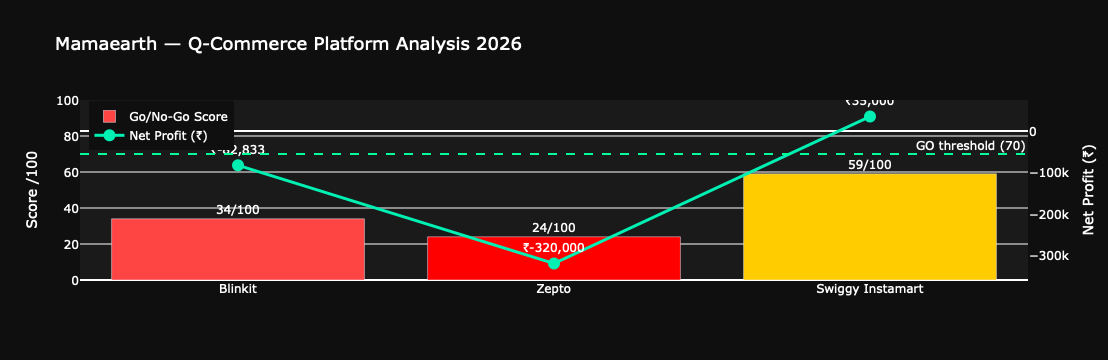


✅ CASE STUDY COMPLETE — Mamaearth x Q-Commerce 2026
📊 Analyst: Bharanidhar S
🔗 Tool: https://qcommerce-analyzer-lbm2shxfnffcrjezpnfwj2.streamlit.app/


In [11]:
import plotly.graph_objects as go

platforms = ["Blinkit", "Zepto", "Swiggy Instamart"]
scores = [34, 24, 59]
net_profits = [-82833, -320000, 35000]
take_rates = [59.2, 85.56, 46.11]
verdicts = ["❌ NO-GO", "❌ NO-GO", "⚠️ CAUTION"]
colors = ["#ff4444", "#ff0000", "#ffcc00"]

fig = go.Figure()

# Score bars
fig.add_trace(go.Bar(
    name="Go/No-Go Score",
    x=platforms,
    y=scores,
    marker_color=colors,
    text=[f"{s}/100" for s in scores],
    textposition="outside",
    yaxis="y1"
))

# Net profit line
fig.add_trace(go.Scatter(
    name="Net Profit (₹)",
    x=platforms,
    y=net_profits,
    mode="lines+markers+text",
    line=dict(color="#00f0b4", width=3),
    marker=dict(size=12),
    text=[f"₹{p:,.0f}" for p in net_profits],
    textposition="top center",
    yaxis="y2"
))

fig.update_layout(
    title="Mamaearth — Q-Commerce Platform Analysis 2026",
    paper_bgcolor="#0f0f0f",
    plot_bgcolor="#1a1a1a",
    font_color="white",
    title_font_size=18,
    yaxis=dict(title="Score /100", range=[0, 100]),
    yaxis2=dict(
        title="Net Profit (₹)",
        overlaying="y",
        side="right",
        showgrid=False
    ),
    legend=dict(x=0.01, y=0.99),
    barmode="group"
)

# Threshold line
fig.add_hline(
    y=70, line_dash="dash",
    line_color="#00ff99",
    annotation_text="GO threshold (70)",
    yref="y1"
)

fig.show()

print("\n✅ CASE STUDY COMPLETE — Mamaearth x Q-Commerce 2026")
print("📊 Analyst: Bharanidhar S")
print("🔗 Tool: https://qcommerce-analyzer-lbm2shxfnffcrjezpnfwj2.streamlit.app/")